# SisFall — AFD-CNN Training Notebook (Peak-Centred Windows, Balanced Classes v2)

Same model and preprocessing as `SisFall_train_peak.ipynb`, but **every class has exactly the same number of samples** (equal to the fall-class count).

### Windowing strategy

**Fall class (label 0):** one window per recording, centred on the global-maximum peak of ‖a‖.

**Non-fall / ADL classes:** `extract_all_peaks` extracts *all* non-overlapping peak windows from each recording (greedy, highest-energy first).  After the global-max window is extracted its region is suppressed and the process repeats, yielding windows ranked by peak magnitude.  All candidate windows across all recordings for a class are then pooled.

### Per-class balancing
| Situation | Action |
|---|---|
| candidates ≥ TARGET | keep top TARGET by peak magnitude |
| candidates < TARGET | keep all + **random oversample with replacement** to reach TARGET |

TARGET = number of fall windows (nominally 298), so every class ends up with exactly the same count.

Checkpoint → `model/sisfall_peak_balanced_v2_model.ckpt`  
CSVs → `data/sisfall_peak_balanced_v2_{train,test}.csv`

**SisFall activity → class mapping:**

| SisFall codes | Class label | Activity |
|---|---|---|
| F01–F15 | 0 | **Fall** |
| D01, D02 | 2 | Walk |
| D03, D04 | 3 | Jog |
| D19 | 4 | Jump |
| D05 | 5 | Up-stairs |
| D06 | 6 | Down-stairs |
| D07, D08 | 7 | Stand→Sit |
| D09, D10 | 9 | Sit→Stand |

## 1. Setup

In [17]:
import sys, os
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

import importlib, cnn as cnn_module
importlib.reload(cnn_module)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.4.4


## 2. Configuration

In [18]:
SISFALL_PATH    = 'SisFall_dataset'
MODEL_SAVE_PATH = 'model/sisfall_peak_balanced_v2_model.ckpt'
TRAIN_CSV       = 'data/sisfall_peak_balanced_v2_train.csv'
TEST_CSV        = 'data/sisfall_peak_balanced_v2_test.csv'

CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NUM   = len(CLASS_LIST)
CLASS_NAMES = {
    0: 'Fall', 2: 'Walk', 3: 'Jog', 4: 'Jump',
    5: 'Up-stairs', 6: 'Down-stairs', 7: 'Stand\u2192Sit', 9: 'Sit\u2192Stand'
}

CODE_TO_LABEL = {
    **{f'F{i:02d}': 0 for i in range(1, 16)},
    'D01': 2, 'D02': 2,
    'D03': 3, 'D04': 3,
    'D19': 4,
    'D05': 5,
    'D06': 6,
    'D07': 7, 'D08': 7,
    'D09': 9, 'D10': 9,
}

WINDOW      = 200   # 2 s at 100 Hz
HALF_WINDOW = WINDOW // 2

# Desired samples per class.  The actual target is set to min(fall_count, TARGET_COUNT)
# after data collection so it always matches the real fall count.
TARGET_COUNT = 298

print('Classes:', CLASS_LIST)
print('Activity codes tracked:', sorted(CODE_TO_LABEL.keys()))
print(f'Configured target per class: {TARGET_COUNT}')

Classes: [0, 2, 3, 4, 5, 6, 7, 9]
Activity codes tracked: ['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D19', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15']
Configured target per class: 298


## 3. Helper Functions

In [19]:
def parse_sisfall_txt(filepath):
    """Read a SisFall .txt file → float32 array (N, 9) of raw ADC values."""
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line:
                continue
            try:
                parts = [int(x.strip()) for x in line.split(',')]
                if len(parts) == 9:
                    rows.append(parts)
            except ValueError:
                pass
    return np.array(rows, dtype=np.float32) if rows else None


def normalize_adxl345(raw):
    """Map ADXL345 13-bit ADC values in [-4096, 4095] linearly to [0, 255]."""
    return np.clip((raw + 4096.0) / 8192.0 * 255.0, 0.0, 255.0)


def extract_peak_window(arr, window=200):
    """
    Single max-peak window from arr (T, 3).
    Returns (window_arr, peak_idx) or (None, None) if the recording is too short.
    """
    n = len(arr)
    if n < window:
        return None, None
    magnitude = np.linalg.norm(arr, axis=1)
    peak_idx  = int(np.argmax(magnitude))
    start     = max(0, min(peak_idx - window // 2, n - window))
    return arr[start:start + window], peak_idx


def extract_all_peaks(arr, window=200):
    """
    Iteratively find all non-overlapping peak windows from arr (T, 3).

    Each iteration:
      1. Find the global argmax of the vector-magnitude signal.
      2. Extract a window centred on that index.
      3. Suppress the extracted window region (set magnitude to 0).
      4. Repeat until no non-zero magnitude remains.

    Returns list of (win_arr (window,3), peak_magnitude) in descending
    peak-magnitude order (greedy — highest-energy windows first).
    """
    n = len(arr)
    if n < window:
        return []

    magnitude = np.linalg.norm(arr, axis=1).copy()
    results   = []

    while True:
        peak_mag = float(magnitude.max())
        if peak_mag == 0.0:
            break
        peak_idx = int(np.argmax(magnitude))
        start    = max(0, min(peak_idx - window // 2, n - window))
        results.append((arr[start:start + window].copy(), peak_mag))
        magnitude[start:start + window] = 0.0   # suppress extracted region

    return results   # descending by peak_mag


print('Helper functions defined.')

Helper functions defined.


## 4. Collect and Balance Windows

In [20]:
np.random.seed(42)

skip_prefixes = {'desktop', 'Links', 'Readme'}

# ── Stage 1: collect all candidate windows ────────────────────────────────────
# Falls    → one window per recording (max peak)
# Non-falls → all non-overlapping peak windows per recording
candidate_windows = {lbl: [] for lbl in CLASS_LIST}  # label → [(flat_600, peak_mag)]

for subj in sorted(os.listdir(SISFALL_PATH)):
    subj_path = os.path.join(SISFALL_PATH, subj)
    if not os.path.isdir(subj_path):
        continue

    for fname in sorted(os.listdir(subj_path)):
        if not fname.endswith('.txt'):
            continue
        if any(fname.startswith(p) for p in skip_prefixes):
            continue

        code = fname.split('_')[0]
        if code not in CODE_TO_LABEL:
            continue

        label = CODE_TO_LABEL[code]

        raw = parse_sisfall_txt(os.path.join(subj_path, fname))
        if raw is None or len(raw) < WINDOW * 2:
            continue

        raw_ds  = raw[::2]        # downsample 200 Hz → 100 Hz
        acc_raw = raw_ds[:, 0:3]  # ADXL345 columns

        if label == 0:
            win_raw, peak_idx = extract_peak_window(acc_raw, window=WINDOW)
            if win_raw is not None:
                peak_mag = float(np.linalg.norm(acc_raw, axis=1)[peak_idx])
                candidate_windows[label].append(
                    (normalize_adxl345(win_raw).flatten().astype(np.float32), peak_mag)
                )
        else:
            for win_raw, peak_mag in extract_all_peaks(acc_raw, window=WINDOW):
                candidate_windows[label].append(
                    (normalize_adxl345(win_raw).flatten().astype(np.float32), peak_mag)
                )

# ── Stage 2: balance every class to exactly TARGET samples ────────────────────
# Falls  : keep all  → this count defines TARGET
# Non-falls:
#   candidates >= TARGET  →  keep top TARGET (highest peak magnitude)
#   candidates <  TARGET  →  keep all + random oversample with replacement
n_falls = len(candidate_windows[0])
TARGET  = min(n_falls, TARGET_COUNT)

print(f'Fall windows collected: {n_falls}  →  TARGET = {TARGET}')
print()

X_acc_list = []
y_list     = []

for lbl in CLASS_LIST:
    windows = candidate_windows[lbl]

    if lbl != 0:
        n_cand = len(windows)
        windows.sort(key=lambda x: -x[1])   # sort by peak magnitude descending

        if n_cand >= TARGET:
            windows = windows[:TARGET]
        else:
            extra_idxs = np.random.choice(n_cand, size=TARGET - n_cand, replace=True)
            windows    = windows + [windows[i] for i in extra_idxs]

    for win_flat, _ in windows:
        X_acc_list.append(win_flat)
        y_list.append(lbl)

X_acc = np.array(X_acc_list, dtype=np.float32)   # (N, 600)
y     = np.array(y_list, dtype=int)

print(f'Total windows after balancing: {len(X_acc)}')
print(f'Sensor value range: [{X_acc.min():.1f}, {X_acc.max():.1f}]')
print()
print(f'{"Class":>12s}  {"Candidates":>11}  {"Kept":>6}  {"Oversampled":>12}')
print('-' * 50)
for lbl in CLASS_LIST:
    n_cand = len(candidate_windows[lbl])
    n_kept = int((y == lbl).sum())
    n_over = max(0, TARGET - n_cand) if lbl != 0 else 0
    flag   = '  ← oversampled' if n_over > 0 else ''
    print(f'{CLASS_NAMES[lbl]:>12s}  {n_cand:>11}  {n_kept:>6}  {n_over:>12}{flag}')

Fall windows collected: 1798  →  TARGET = 298

Total windows after balancing: 3884
Sensor value range: [0.0, 254.9]

       Class   Candidates    Kept   Oversampled
--------------------------------------------------
        Fall         1798    1798             0
        Walk         5926     298             0
         Jog         5698     298             0
        Jump         1105     298             0
   Up-stairs         3566     298             0
 Down-stairs         2294     298             0
   Stand→Sit         3461     298             0
   Sit→Stand         3387     298             0


## 5. Visualise Peak Detection

One fall and one Walk recording — full signal with the max peak and extracted window highlighted.

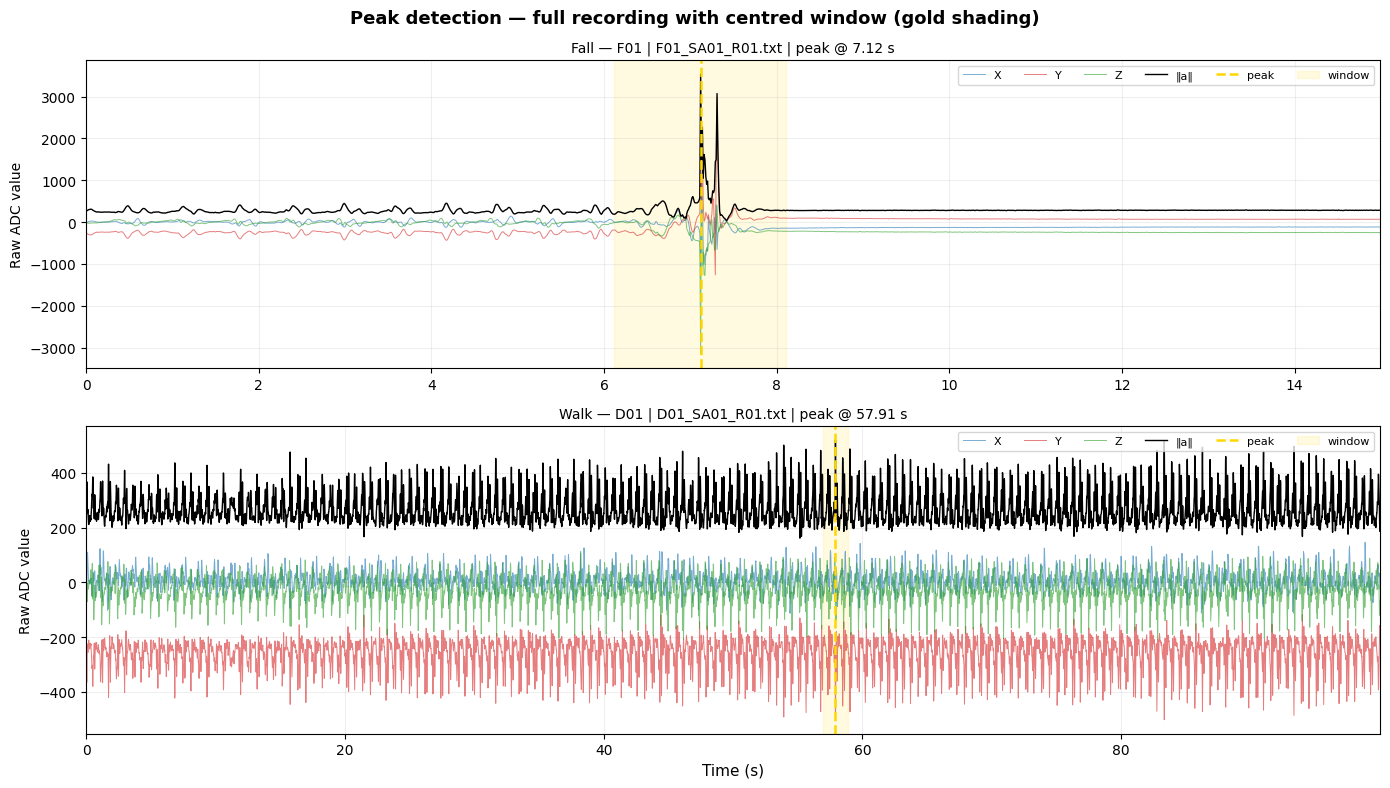

In [21]:
def load_raw_for_vis(label_filter, code_filter=None):
    for subj in sorted(os.listdir(SISFALL_PATH)):
        subj_path = os.path.join(SISFALL_PATH, subj)
        if not os.path.isdir(subj_path):
            continue
        for fname in sorted(os.listdir(subj_path)):
            if not fname.endswith('.txt'):
                continue
            code = fname.split('_')[0]
            if CODE_TO_LABEL.get(code) != label_filter:
                continue
            if code_filter and code != code_filter:
                continue
            raw = parse_sisfall_txt(os.path.join(subj_path, fname))
            if raw is None or len(raw) < WINDOW * 2:
                continue
            raw_ds  = raw[::2]
            acc_raw = raw_ds[:, 0:3]
            _, peak_idx = extract_peak_window(acc_raw, window=WINDOW)
            return acc_raw, peak_idx, fname
    return None, None, None


fig, axes = plt.subplots(2, 1, figsize=(14, 8))
AXIS_COLORS = ['#1f77b4', '#d62728', '#2ca02c']

for ax, (lbl, code_f, title_tag) in zip(axes, [
        (0, 'F01', 'Fall \u2014 F01'),
        (2, 'D01', 'Walk \u2014 D01'),
]):
    acc_raw, peak_idx, fname = load_raw_for_vis(lbl, code_f)
    if acc_raw is None:
        ax.set_title(f'{title_tag}: no file found')
        continue
    t   = np.arange(len(acc_raw)) / 100.0
    mag = np.linalg.norm(acc_raw, axis=1)
    for i, (aname, color) in enumerate(zip(['X', 'Y', 'Z'], AXIS_COLORS)):
        ax.plot(t, acc_raw[:, i], color=color, linewidth=0.7, alpha=0.6, label=aname)
    ax.plot(t, mag, color='black', linewidth=1.0, label='\u2016a\u2016')
    ax.axvline(t[peak_idx], color='gold', linewidth=1.8, linestyle='--', label='peak')
    win_start = max(0, min(peak_idx - HALF_WINDOW, len(acc_raw) - WINDOW))
    ax.axvspan(t[win_start], t[win_start + WINDOW - 1], alpha=0.12, color='gold', label='window')
    ax.set_xlim(0, t[-1])
    ax.set_title(f'{title_tag} | {fname} | peak @ {t[peak_idx]:.2f} s', fontsize=10)
    ax.set_ylabel('Raw ADC value')
    ax.legend(loc='upper right', fontsize=8, ncol=6)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (s)', fontsize=11)
fig.suptitle('Peak detection \u2014 full recording with centred window (gold shading)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5b. Visualise Multi-Peak Extraction

All non-overlapping windows extracted from one Walk recording, colour-coded by rank.

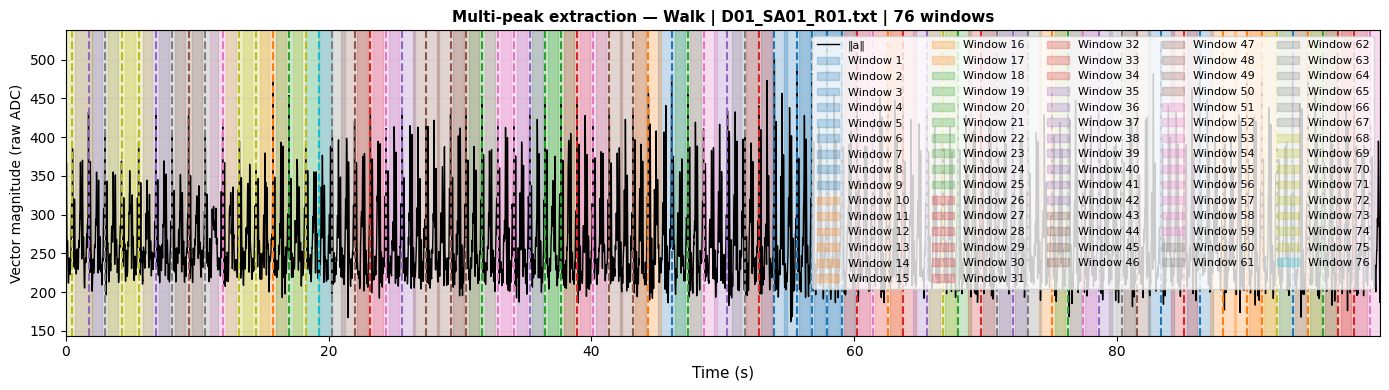

Peak magnitudes: ['519.9', '518.0', '501.1', '496.8', '493.6', '487.4', '486.4', '481.9', '478.9', '478.3', '476.0', '470.4', '469.7', '467.3', '459.6', '456.4', '456.2', '455.7', '453.8', '453.6', '452.7', '452.3', '451.5', '450.0', '449.9', '449.7', '448.6', '448.3', '447.5', '444.6', '443.8', '440.3', '437.7', '436.6', '436.4', '435.9', '434.8', '434.7', '434.0', '431.8', '431.7', '430.9', '429.9', '429.5', '429.5', '428.7', '427.9', '427.5', '423.3', '420.9', '420.6', '418.3', '417.0', '415.4', '413.9', '413.2', '411.4', '410.9', '410.6', '409.3', '408.1', '400.9', '400.8', '399.6', '399.5', '399.3', '397.0', '395.1', '394.5', '393.7', '393.4', '393.1', '385.2', '369.0', '357.6', '240.4']


In [22]:
demo_acc_raw, demo_peaks, demo_fname = None, [], ''

for subj in sorted(os.listdir(SISFALL_PATH)):
    subj_path = os.path.join(SISFALL_PATH, subj)
    if not os.path.isdir(subj_path):
        continue
    for fname in sorted(os.listdir(subj_path)):
        if not fname.endswith('.txt'):
            continue
        if fname.split('_')[0] not in ('D01', 'D02'):
            continue
        raw = parse_sisfall_txt(os.path.join(subj_path, fname))
        if raw is None or len(raw) < WINDOW * 2:
            continue
        acc_raw = raw[::2][:, 0:3]
        peaks   = extract_all_peaks(acc_raw, window=WINDOW)
        if len(peaks) >= 2:
            demo_acc_raw, demo_peaks, demo_fname = acc_raw, peaks, fname
            break
    if demo_acc_raw is not None:
        break

if demo_acc_raw is None:
    print('No suitable Walk recording found.')
else:
    t   = np.arange(len(demo_acc_raw)) / 100.0
    mag = np.linalg.norm(demo_acc_raw, axis=1)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t, mag, color='black', linewidth=1.0, label='\u2016a\u2016')

    colors_win   = plt.cm.tab10(np.linspace(0, 0.9, len(demo_peaks)))
    mag_copy     = mag.copy()
    for rank, color in enumerate(colors_win):
        peak_idx = int(np.argmax(mag_copy))
        start    = max(0, min(peak_idx - HALF_WINDOW, len(demo_acc_raw) - WINDOW))
        ax.axvspan(t[start], t[start + WINDOW - 1], alpha=0.25, color=color,
                   label=f'Window {rank + 1}')
        ax.axvline(t[peak_idx], color=color, linewidth=1.5, linestyle='--')
        mag_copy[start:start + WINDOW] = 0.0

    ax.set_xlim(0, t[-1])
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Vector magnitude (raw ADC)', fontsize=10)
    ax.set_title(
        f'Multi-peak extraction \u2014 Walk | {demo_fname} | {len(demo_peaks)} windows',
        fontsize=11, fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=8, ncol=5)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
    print('Peak magnitudes:', [f'{p[1]:.1f}' for p in demo_peaks])

## 6. Visualise Sample Windows

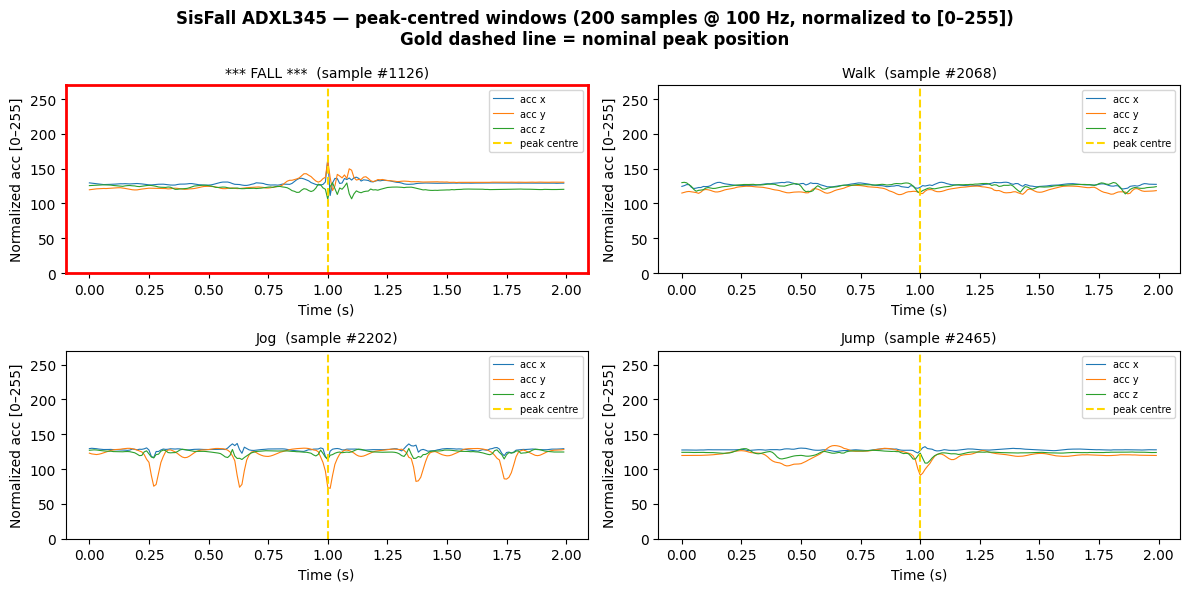

In [23]:
np.random.seed(42)
show_labels = [0, 2, 3, 4]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, label in zip(axes.flat, show_labels):
    idxs     = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    acc_data = X_acc[sample_i].reshape(200, 3)
    t        = np.arange(200) / 100.0
    for i, (aname, color) in enumerate(zip(['x', 'y', 'z'], colors)):
        ax.plot(t, acc_data[:, i], color=color, linewidth=0.8, label=f'acc {aname}')
    ax.axvline(1.0, color='gold', linewidth=1.5, linestyle='--', label='peak centre')
    tag = '*** FALL ***' if label == 0 else CLASS_NAMES[label]
    ax.set_title(f'{tag}  (sample #{sample_i})', fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized acc [0\u2013255]')
    ax.legend(fontsize=7)
    ax.set_ylim(0, 270)
    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle(
    'SisFall ADXL345 \u2014 peak-centred windows (200 samples @ 100 Hz, normalized to [0\u2013255])\n'
    'Gold dashed line = nominal peak position',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

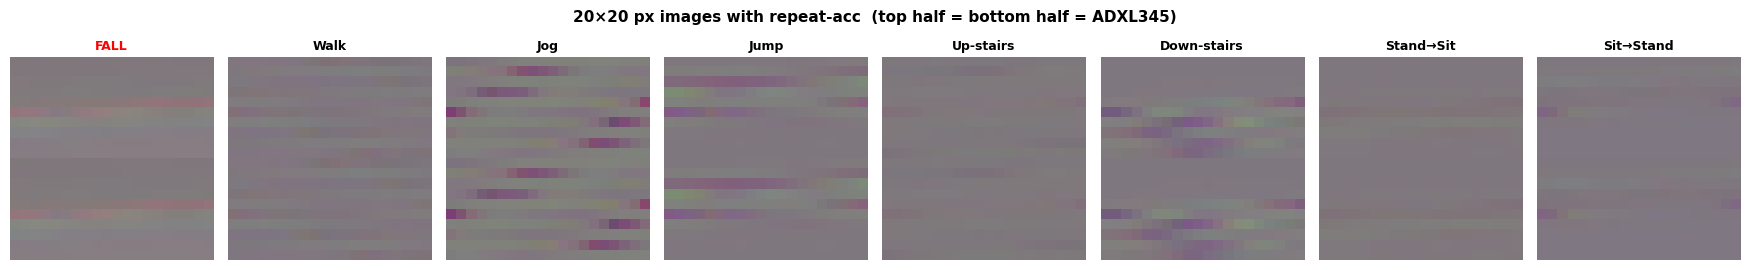

In [24]:
def to_image_repeat(acc_flat):
    repeated = np.concatenate([acc_flat, acc_flat])
    return repeated.reshape(20, 20, 3) / 255.0

np.random.seed(7)
fig, axes = plt.subplots(1, len(CLASS_LIST), figsize=(2.2 * len(CLASS_LIST), 2.8))
for ax, label in zip(axes, CLASS_LIST):
    idxs     = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    ax.imshow(to_image_repeat(X_acc[sample_i]))
    tag = 'FALL' if label == 0 else CLASS_NAMES[label]
    ax.set_title(tag, fontsize=9, color='red' if label == 0 else 'black', fontweight='bold')
    ax.axis('off')

fig.suptitle('20\u00d720 px images with repeat-acc  (top half = bottom half = ADXL345)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Train / Test Split and Save CSVs

Stratified 80 / 20 split. CSVs store the 600 raw acc values; the repeat is applied at model-input time.

In [25]:
idx_train, idx_test = train_test_split(
    np.arange(len(X_acc)), test_size=0.2, random_state=42, stratify=y
)

X_acc_train, X_acc_test = X_acc[idx_train], X_acc[idx_test]
y_train,     y_test     = y[idx_train],     y[idx_test]

print(f'Train: {len(X_acc_train)} samples | Test: {len(X_acc_test)} samples')
print()
print(f'{"Class":>12s}  {"Train":>7}  {"Test":>6}')
print('-' * 32)
for lbl in CLASS_LIST:
    print(f'{CLASS_NAMES[lbl]:>12s}  {(y_train == lbl).sum():>7}  {(y_test == lbl).sum():>6}')

Train: 3107 samples | Test: 777 samples

       Class    Train    Test
--------------------------------
        Fall     1438     360
        Walk      239      59
         Jog      239      59
        Jump      238      60
   Up-stairs      238      60
 Down-stairs      238      60
   Stand→Sit      239      59
   Sit→Stand      238      60


In [26]:
col_names = ['label'] + [str(i + 1) for i in range(600)]

train_df = pd.DataFrame(np.column_stack([y_train.astype(float), X_acc_train]), columns=col_names)
train_df['label'] = y_train
train_df.to_csv(TRAIN_CSV, index=False)

test_df = pd.DataFrame(np.column_stack([y_test.astype(float), X_acc_test]), columns=col_names)
test_df['label'] = y_test
test_df.to_csv(TEST_CSV, index=False)

print(f'Saved  {TRAIN_CSV}  ({len(train_df)} rows)')
print(f'Saved  {TEST_CSV}   ({len(test_df)} rows)')

Saved  data/sisfall_peak_balanced_v2_train.csv  (3107 rows)
Saved  data/sisfall_peak_balanced_v2_test.csv   (777 rows)


## 8. Build Model Inputs (Apply Repeat-Acc)

The model expects 1200 values. Repeat-acc: `[acc_600, acc_600]`.

In [27]:
def apply_repeat_acc(X_600):
    return np.hstack([X_600, X_600]).astype(np.float32)

def to_onehot(labels_arr, class_list):
    y_oh = np.zeros((len(labels_arr), len(class_list)), dtype=np.float32)
    for i, lbl in enumerate(labels_arr):
        y_oh[i, class_list.index(lbl)] = 1.0
    return y_oh

X_model_train = apply_repeat_acc(X_acc_train)
X_model_test  = apply_repeat_acc(X_acc_test)
y_train_oh    = to_onehot(y_train, CLASS_LIST)
y_test_oh     = to_onehot(y_test,  CLASS_LIST)

print(f'Train input: {X_model_train.shape}  |  Test input: {X_model_test.shape}')
print(f'Value range: [{X_model_train.min():.1f}, {X_model_train.max():.1f}]')

Train input: (3107, 1200)  |  Test input: (777, 1200)
Value range: [0.0, 254.9]


## 9. Build TF Graph and Train

In [28]:
TRAIN_STEPS   = 5000
BATCH_SIZE    = 50
LEARNING_RATE = 0.001

tf.reset_default_graph()

x_ph = tf.placeholder(tf.float32, [None, 1200], name='input')
y_ph = tf.placeholder(tf.float32, [None, CLASS_NUM], name='labels')

logits, keep_prob_ph = cnn_module.fall_net(x_ph)

loss_op    = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels=y_ph, logits=logits))
train_op   = tf.train.AdamOptimizer(LEARNING_RATE).minimize(loss_op)
correct_op = tf.equal(tf.argmax(logits, 1), tf.argmax(y_ph, 1))
acc_op     = tf.reduce_mean(tf.cast(correct_op, tf.float32))
probs_op   = tf.nn.softmax(logits)

saver = tf.train.Saver()
sess  = tf.Session()
sess.run(tf.global_variables_initializer())

print(f'Graph built. Training on {len(X_model_train)} samples for {TRAIN_STEPS} steps...')

Graph built. Training on 3107 samples for 5000 steps...


In [29]:
n_train = len(X_model_train)
perm    = np.random.permutation(n_train)
ptr     = 0

log_steps, log_loss, log_acc = [], [], []

for step in range(1, TRAIN_STEPS + 1):
    if ptr + BATCH_SIZE > n_train:
        perm = np.random.permutation(n_train)
        ptr  = 0
    batch_idx = perm[ptr:ptr + BATCH_SIZE]
    ptr += BATCH_SIZE

    _, loss_val = sess.run([train_op, loss_op],
                           feed_dict={x_ph: X_model_train[batch_idx],
                                      y_ph: y_train_oh[batch_idx],
                                      keep_prob_ph: 0.5})
    if step % 500 == 0:
        acc_val = acc_op.eval(session=sess,
                              feed_dict={x_ph: X_model_train[batch_idx],
                                         y_ph: y_train_oh[batch_idx],
                                         keep_prob_ph: 1.0})
        log_steps.append(step)
        log_loss.append(loss_val)
        log_acc.append(acc_val)
        print(f'Step {step:5d}  |  loss = {loss_val:.4f}  |  batch acc = {acc_val:.4f}')

save_path = saver.save(sess, MODEL_SAVE_PATH)
print(f'\nModel saved to {save_path}')

Step   500  |  loss = 0.0485  |  batch acc = 1.0000
Step  1000  |  loss = 0.0515  |  batch acc = 0.9800
Step  1500  |  loss = 0.0034  |  batch acc = 1.0000
Step  2000  |  loss = 0.0025  |  batch acc = 1.0000
Step  2500  |  loss = 0.0326  |  batch acc = 1.0000
Step  3000  |  loss = 0.0000  |  batch acc = 1.0000
Step  3500  |  loss = 0.0006  |  batch acc = 1.0000
Step  4000  |  loss = 0.0001  |  batch acc = 1.0000
Step  4500  |  loss = 0.0044  |  batch acc = 1.0000
Step  5000  |  loss = 0.0001  |  batch acc = 1.0000

Model saved to model/sisfall_peak_balanced_v2_model.ckpt


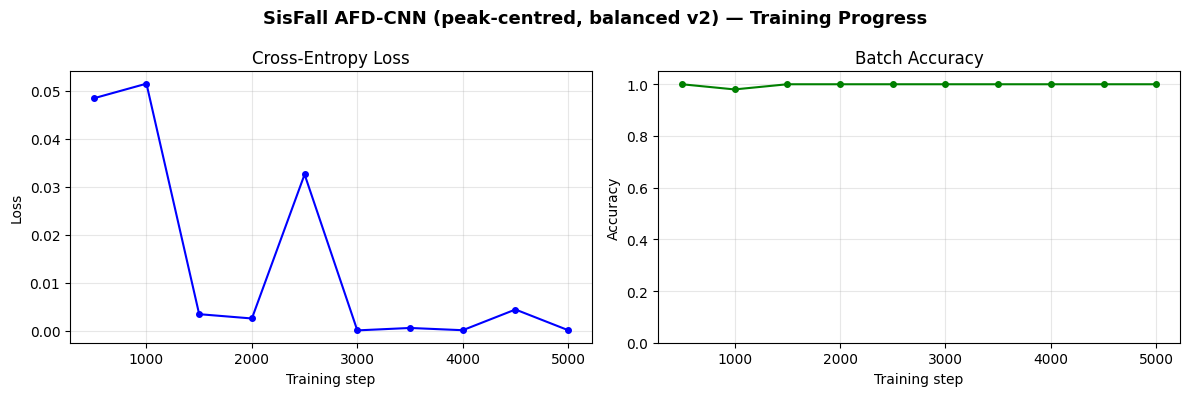

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(log_steps, log_loss, 'b-o', markersize=4)
ax1.set_title('Cross-Entropy Loss')
ax1.set_xlabel('Training step')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(log_steps, log_acc, 'g-o', markersize=4)
ax2.set_title('Batch Accuracy')
ax2.set_xlabel('Training step')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

fig.suptitle('SisFall AFD-CNN (peak-centred, balanced v2) \u2014 Training Progress',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Evaluate on Train and Test Sets

In [31]:
def run_inference(X):
    EVAL_BATCH = 256
    all_probs  = []
    for start in range(0, len(X), EVAL_BATCH):
        p = sess.run(probs_op, feed_dict={x_ph: X[start:start + EVAL_BATCH], keep_prob_ph: 1.0})
        all_probs.append(p)
    all_probs   = np.vstack(all_probs)
    pred_idx    = np.argmax(all_probs, axis=1)
    pred_labels = np.array([CLASS_LIST[i] for i in pred_idx])
    return pred_labels, all_probs


for split_name, X_split, y_split in [
        ('Train', X_model_train, y_train),
        ('Test',  X_model_test,  y_test)]:

    pred_labels, _ = run_inference(X_split)
    overall = np.mean(pred_labels == y_split)

    print(f'=== {split_name} set ({len(y_split)} samples) ===')
    print(f'Overall accuracy: {overall:.4f}  ({overall:.2%})')
    print(f'{"Class":>12s}  {"N":>5}  {"Sensitivity":>12}  {"Specificity":>12}')
    print('-' * 48)
    for lbl in CLASS_LIST:
        acc, sens, spec = cnn_module.evaluate(pred_labels, y_split, lbl)
        n_cls = int((y_split == lbl).sum())
        print(f'{CLASS_NAMES[lbl]:>12s}  {n_cls:>5}  {sens:>12.4f}  {spec:>12.4f}')
    print()

=== Train set (3107 samples) ===
Overall accuracy: 0.9997  (99.97%)
       Class      N   Sensitivity   Specificity
------------------------------------------------
        Fall   1438        1.0000        1.0000
        Walk    239        1.0000        1.0000
         Jog    239        1.0000        1.0000
        Jump    238        1.0000        1.0000
   Up-stairs    238        1.0000        1.0000
 Down-stairs    238        1.0000        1.0000
   Stand→Sit    239        0.9958        1.0000
   Sit→Stand    238        1.0000        0.9997

=== Test set (777 samples) ===
Overall accuracy: 0.9807  (98.07%)
       Class      N   Sensitivity   Specificity
------------------------------------------------
        Fall    360        0.9889        1.0000
        Walk     59        0.9831        1.0000
         Jog     59        1.0000        0.9986
        Jump     60        0.9833        0.9986
   Up-stairs     60        0.9833        0.9958
 Down-stairs     60        0.9833        0.9972

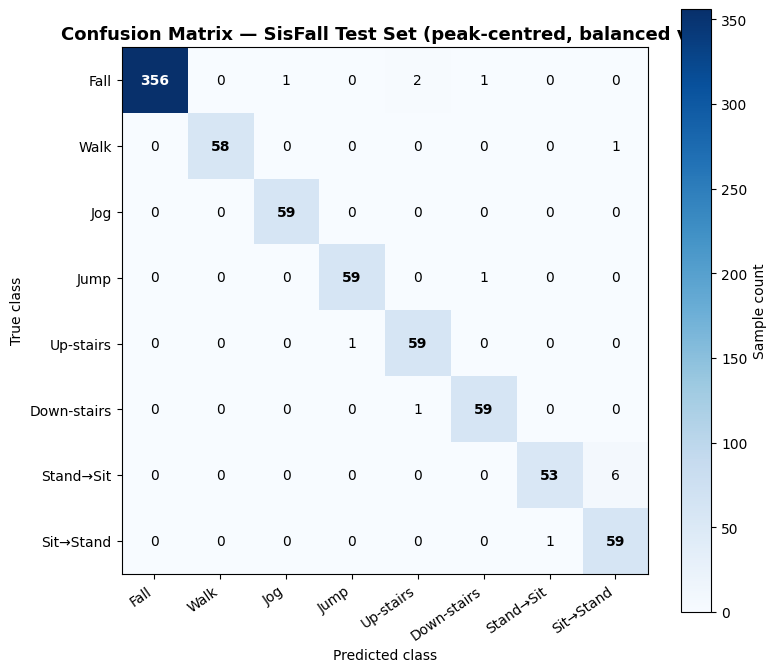

Training complete. Session closed.
Checkpoint: model/sisfall_peak_balanced_v2_model.ckpt
Test CSV:   data/sisfall_peak_balanced_v2_test.csv


In [32]:
pred_test, _ = run_inference(X_model_test)
label_names  = [CLASS_NAMES[l] for l in CLASS_LIST]
cm = confusion_matrix(y_test, pred_test, labels=CLASS_LIST)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, label='Sample count')
ax.set_xticks(range(len(CLASS_LIST)))
ax.set_yticks(range(len(CLASS_LIST)))
ax.set_xticklabels(label_names, rotation=35, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title('Confusion Matrix \u2014 SisFall Test Set (peak-centred, balanced v2)',
             fontsize=13, fontweight='bold')
for i in range(len(CLASS_LIST)):
    for j in range(len(CLASS_LIST)):
        val    = cm[i, j]
        color  = 'white' if val > cm.max() / 2 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=10, color=color, fontweight=weight)

plt.tight_layout()
plt.show()

sess.close()
print('Training complete. Session closed.')
print(f'Checkpoint: {MODEL_SAVE_PATH}')
print(f'Test CSV:   {TEST_CSV}')